In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor, DummyRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import class_likelihood_ratios, classification_report
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA

In [2]:
from google.colab import files
uploaded = files.upload() # Opens a dialog to select and upload files

Saving South Dakota State_0466.csv to South Dakota State_0466.csv


In [468]:
df_0 = pd.read_csv('South Dakota State_0466.csv')
df = df_0.dropna(axis='columns', how='all').copy()

In [469]:
# Let's see the shape first
print(f"Cols: {df.shape[1]}")
print(f"Rows: {df.shape[0]}")

Cols: 113
Rows: 259


In [470]:
# dropped some columns that make no sense, yet!
df.drop(columns=['Tilt', 'KorBB', 'PlayResult',
                 'PitchNo', 'PitchUUID', 'BatterId', 'PitcherId'], inplace=True)
# Typos!
df.replace('RIse', 'Rise', inplace=True)
# dropped columns that have only one unique value, except for a few.
for col in df.columns:
  #print(f"{col}: {df[col].nunique()}")
  if df[col] is any(['y0', 'yt_PitchSpinConfidence', 'yt_HitSpinConfidence', 'yt_ZoneAccuracy']):
    pass

  if df[col].nunique() <= 1:
    print(f"Dropping {col}")
    df = df.drop(col, axis=1)

# Also drop all the batting columns
df.drop(columns=['ZoneSpeed', 'VertApprAngle', 'HorzApprAngle',
                'ZoneTime', 'ExitSpeed', 'Angle', 'Direction', 'HitSpinRate',
                'Distance', 'HitType'], inplace=True)


Dropping Date
Dropping y0
Dropping HomeTeam
Dropping AwayTeam
Dropping GameID
Dropping yt_PitchSpinConfidence
Dropping yt_HitSpinConfidence
Dropping yt_ZoneAccuracy
Dropping CatcherId


In [471]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
cat_cols = cat_cols.drop('Time')
cat_df = df[cat_cols].dropna().copy()
for col in cat_cols:
  print(f"{col}: {df[col].unique()}")

Pitcher: ['Kynlee Bowlin' 'Grace  Proctor' 'Maddie Furniss' 'Keira Carrillo'
 'Bella  Macmahon' 'Tayler Baker']
PitcherThrows: ['Right' 'Left']
PitcherTeam: ['Uta fall 25' 'South dakota state [sou03:2025]']
Batter: ['Bria Riebel' 'Akayla Barnard' 'Amanda Vacanti' 'Ella  Berlange'
 'Kaylee Schweitzer' 'Mia Mcnulty' 'Valeria Feeney' 'Dee Mcclarity'
 'Kelsey Creech' 'Emma Vike' 'Emma Christensen' 'Abby Gentry' 'Alli Boyle'
 'Quinn Marnocha' 'Peyton Holland' 'Marley Neises' 'Talia Maldonado'
 'Cameron Cooper' 'Kaitlyn Sailor' 'Tayler Baker' 'Taylor Minor']
BatterSide: ['Right' 'Left']
BatterTeam: ['South dakota state [sou03:2025]' 'Uta fall 25']
Top/Bottom: ['Top' 'Bottom']
TaggedPitchType: ['Screw' 'Change' 'Rise' 'Curve' nan 'Fast']
PitchCall: ['StrikeCalled' 'Foul' 'InPlay' 'BallCalled' 'StrikeSwinging' 'HitByPitch'
 nan]
yt_ReleaseAccuracy: ['high' nan 'medium']
Catcher: ['Mia Mcnulty' 'Abby Gentry' nan]
CatcherTeam: ['Uta fall 25' 'South dakota state [sou03:2025]' nan]
yt_AeroModel: [

In [472]:
print(f"Cols: {df.shape[1]}")
print(f"Rows: {df.shape[0]}")

Cols: 87
Rows: 259


/tmp/ipykernel_2461/2476840689.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
/tmp/ipykernel_2461/2476840689.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)


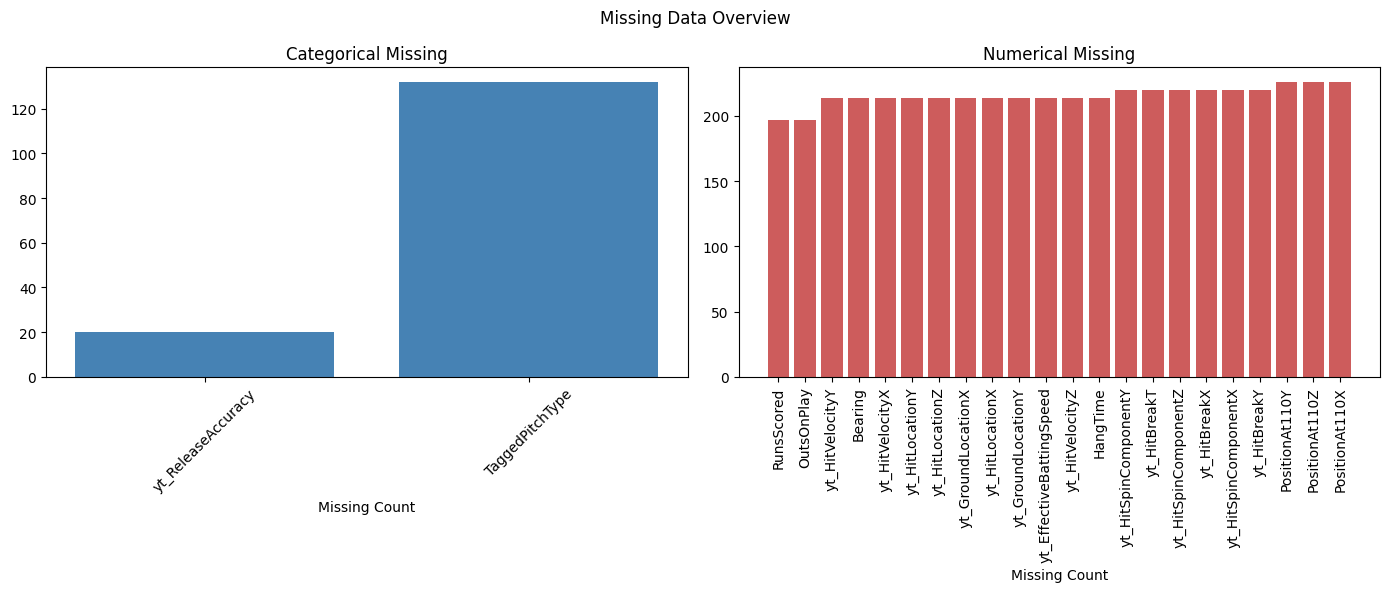

In [473]:
# Split columns by dtype
cat_cols = df.select_dtypes(include=['object', 'category']).columns
num_cols = df.select_dtypes(include=['number']).columns

# Missing counts
missing_cat = df[cat_cols].isna().sum().sort_values()
missing_num = df[num_cols].isna().sum().sort_values()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Categorical
ax1.bar(missing_cat[missing_cat > 5].index, missing_cat[missing_cat > 5].values, color='steelblue')
ax1.set_title("Categorical Missing")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.set_xlabel("Missing Count")

# Numerical
ax2.bar(missing_num[missing_num > 25].index, missing_num[missing_num > 25].values, color='indianred')
ax2.set_title("Numerical Missing")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
ax2.set_xlabel("Missing Count")

fig.suptitle("Missing Data Overview")
plt.tight_layout()
plt.show()

First, we see what we can do about filling in the missing categorical columns.
* see types for TaggedPitchType, HitType

In [474]:
print("Pitch Type:", df['TaggedPitchType'].unique())
#print("Hit Type:", df['HitType'].unique())


Pitch Type: ['Screw' 'Change' 'Rise' 'Curve' nan 'Fast']


In [475]:
# First we need to see the average speed of each pitcher.
from scipy import stats
df_pitch = df.dropna(subset=['RelSpeed', 'Pitcher']).copy()

pitch_stats = (
    df_pitch.groupby('Pitcher')['RelSpeed']
    .agg(
        Count='count',
        Mean='mean',
        Std='std',
        Median='median',
        Min='min',
        Max='max',
        IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
    ).round(2)
)
print("=== PLAYER PITCHER SUMMARY STATS ===")
print(pitch_stats)

=== PLAYER PITCHER SUMMARY STATS ===
                 Count   Mean   Std  Median    Min    Max   IQR
Pitcher                                                        
Bella  Macmahon      7  64.66  3.55   66.82  59.39  67.06  4.18
Grace  Proctor      51  62.65  1.68   62.83  57.20  64.47  1.57
Keira Carrillo      17  66.67  2.48   66.99  58.28  70.32  1.45
Kynlee Bowlin       42  57.85  5.03   60.11  47.60  62.06  2.52
Maddie Furniss      73  68.51  1.00   68.53  65.68  71.20  1.23
Tayler Baker        49  65.22  4.37   66.75  51.89  68.70  1.85


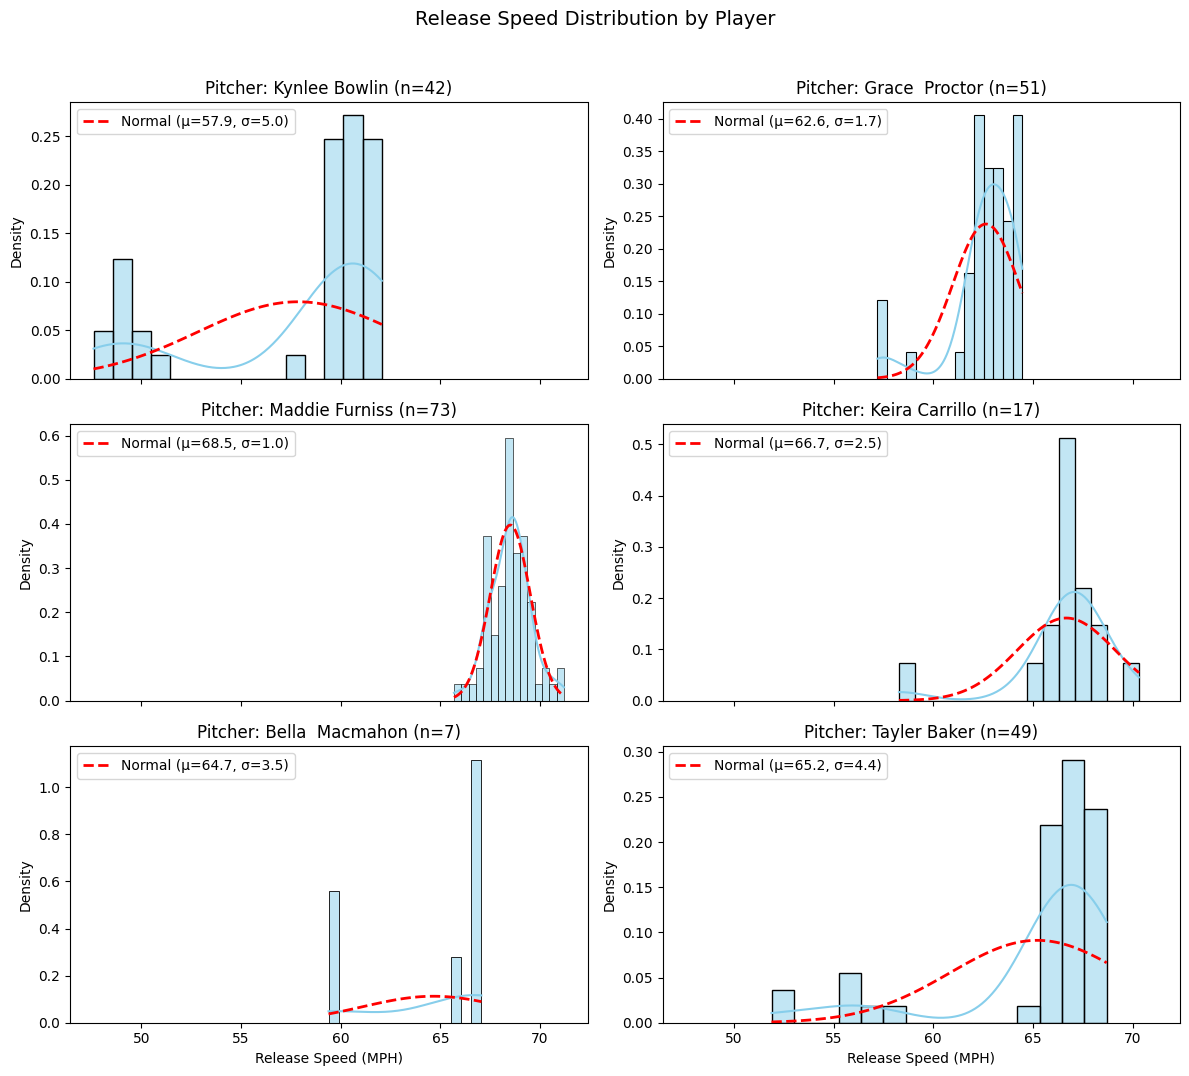

In [476]:
players = df_speed["Pitcher"].unique()
n_players = len(players)

# Calculate grid dimensions (e.g., 2 columns)
n_cols = 2
n_rows = int(np.ceil(n_players / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5 * n_rows), sharex=True)
axes = np.array(axes).reshape(-1)  # Flatten axes array for easy iteration

for i, player in enumerate(players):
    ax = axes[i]
    player_data = df_speed[df_speed["Pitcher"] == player]["RelSpeed"]

    # Histogram + Kernel Density Estimate
    sns.histplot(
        player_data, kde=True, ax=ax, color="skyblue", bins=15, stat="density"
    )

    # Plot fitted Normal distribution line for comparison
    mu, std = player_data.mean(), player_data.std()
    x_range = np.linspace(player_data.min(), player_data.max(), 100)
    ax.plot(
        x_range,
        stats.norm.pdf(x_range, mu, std),
        "r--",
        lw=2,
        label=f"Normal (μ={mu:.1f}, σ={std:.1f})",
    )

    ax.set_title(f"Pitcher: {player} (n={len(player_data)})")
    ax.set_xlabel("Release Speed (MPH)")
    ax.set_ylabel("Density")
    ax.legend(loc="upper left")

# Hide extra empty subplots if grid exceeds n_players
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Release Speed Distribution by Player", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [477]:
from sklearn.ensemble import HistGradientBoostingClassifier

pitch_features = [
    "RelSpeed",
    "VertRelAngle",
    "HorzRelAngle",
    "SpinRate",
    "SpinAxis",
    "VertBreak",
    "InducedVertBreak",
    "HorzBreak",
]

known_pitch = df[df["TaggedPitchType"].notnull()]
missing_pitch = df[df["TaggedPitchType"].isnull()]

if not missing_pitch.empty:
    clf = HistGradientBoostingClassifier(random_state=42)
    clf.fit(known_pitch[pitch_features], known_pitch["TaggedPitchType"])

    df.loc[missing_pitch.index, "TaggedPitchType"] = clf.predict(
        missing_pitch[pitch_features]
    )
    print(f"Successfully imputed {len(missing_pitch)} missing pitch tags!")

Successfully imputed 132 missing pitch tags!


In [478]:
df['TaggedPitchType'].notna().value_counts()

,count
TaggedPitchType,
True,259


/tmp/ipykernel_2461/2476840689.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
/tmp/ipykernel_2461/2476840689.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)


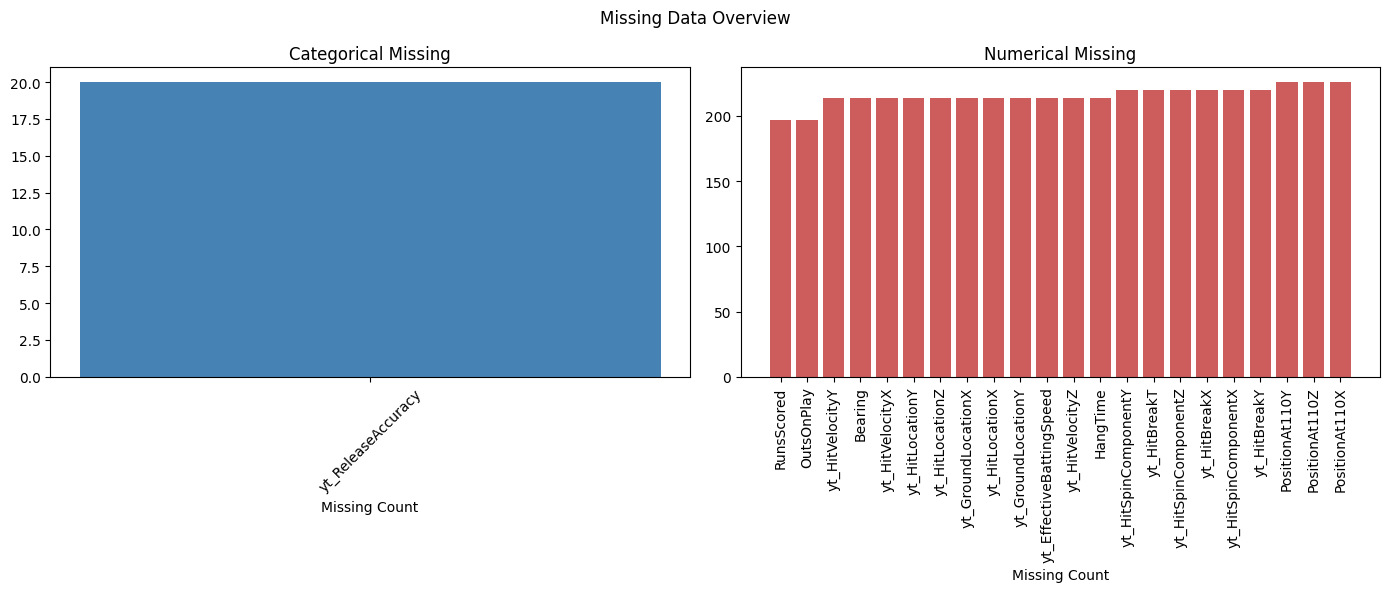

In [479]:
# Split columns by dtype
cat_cols = df.select_dtypes(include=['object', 'category']).columns
num_cols = df.select_dtypes(include=['number']).columns

# Missing counts
missing_cat = df[cat_cols].isna().sum().sort_values()
missing_num = df[num_cols].isna().sum().sort_values()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Categorical
ax1.bar(missing_cat[missing_cat > 5].index, missing_cat[missing_cat > 5].values, color='steelblue')
ax1.set_title("Categorical Missing")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.set_xlabel("Missing Count")

# Numerical
ax2.bar(missing_num[missing_num > 25].index, missing_num[missing_num > 25].values, color='indianred')
ax2.set_title("Numerical Missing")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
ax2.set_xlabel("Missing Count")

fig.suptitle("Missing Data Overview")
plt.tight_layout()
plt.show()

Need to see what the averages are for each speed

In [480]:
# conversions & standardization of some features
angle_features = [
    'SpinAxis',
    #'Direction',
    'Bearing',
    #'VertRelAngle',
    #'HorzRelAngle',
    #'VertApprAngle',
    #'HorzApprAngle',
    #'Angle',


]
for col in angle_features:
    theta = np.deg2rad(df[col])

    df[f'{col}_sin'] = np.sin(theta)
    df[f'{col}_cos'] = np.cos(theta)

df.drop(columns=angle_features, inplace=True)

In [493]:
for i, col in enumerate(df.columns):
  print(f"[{i}], {col}")
#

[0], Time
[1], PAofInning
[2], PitchofPA
[3], Pitcher
[4], PitcherThrows
[5], PitcherTeam
[6], Batter
[7], BatterSide
[8], BatterTeam
[9], Inning
[10], Top/Bottom
[11], Outs
[12], Balls
[13], Strikes
[14], TaggedPitchType
[15], PitchCall
[16], OutsOnPlay
[17], RunsScored
[18], RelSpeed
[19], VertRelAngle
[20], HorzRelAngle
[21], SpinRate
[22], RelHeight
[23], RelSide
[24], Extension
[25], VertBreak
[26], InducedVertBreak
[27], HorzBreak
[28], PlateLocHeight
[29], PlateLocSide
[30], PositionAt110X
[31], PositionAt110Y
[32], PositionAt110Z
[33], HangTime
[34], pfxx
[35], pfxz
[36], x0
[37], z0
[38], vx0
[39], vy0
[40], vz0
[41], ax0
[42], ay0
[43], az0
[44], yt_RelSpeed
[45], yt_RelHeight
[46], yt_RelSide
[47], yt_VertRelAngle
[48], yt_HorzRelAngle
[49], yt_ZoneSpeed
[50], yt_PlateLocHeight
[51], yt_PlateLocSide
[52], yt_VertApprAngle
[53], yt_HorzApprAngle
[54], yt_ZoneTime
[55], yt_HorzBreak
[56], yt_InducedVertBreak
[57], yt_OutOfPlane
[58], yt_EffectiveSpin
[59], yt_GyroSpin
[60], yt

In [509]:
# Seperating numerical features in preparation for PCA:
feature_groups = {

    # Game context
    #"Game_Context": [
    #    1, 2, 19, 20
    #],

    # Pitch velocity and release metrics
    "Velocity": [
        21, 35, 59, 64
    ],

    # Release mechanics
    "Release": [
        22, 23, 27, 28, 29,
        60, 61, 62, 63, 96
    ],

    # Pitch spin characteristics
    "Spin": [
        24,
        73, 74, 75,
        76, 77, 78
    ],

    # Pitch movement
    "Movement": [
        30, 31, 32,
        49, 50,
        70, 71
    ],

    # Plate location
    "Location": [
        33, 34,
        65, 66
    ],

    # Approach trajectory
    "Approach": [
        36, 37, 38,
        67, 68, 69
    ],

    # Raw physics model
    "Trajectory_Physics": [
        51, 52,
        53, 54, 55,
        56, 57, 58
    ],

    # Ball contact metrics
    #"Contact": [
    #    39, 40, 41, 42,
    #],

    # Batted ball flight
    "Flight": [
        43, 44, 45,
        46, 47, 48
    ],

    # Hit trajectory decomposition
    #"Hit_Trajectory": [
    #    79, 80, 81,
    #    84,
    #    85, 86,
    #    87, 88, 89
    #],

    # Batted ball spin
    #"Hit_Spin": [
    #    90, 91, 92
    #],

    # Data quality
    "Confidence": [
        93
    ]
}

In [510]:
import pandas as pd

# 1. Convert integer index lists to ACTUAL column names ONCE
# (Do this on your original dataframe before dropping/modifying any columns)
feature_groups_named = {
    group: [df.columns[i] for i in idxs if i < len(df.columns)]
    for group, idxs in feature_groups.items()
}

# 2. Build your yt_group_dfs and raw_group_dfs using column names safely
yt_group_dfs = {}
raw_group_dfs = {}

for group, cols in feature_groups_named.items():
    # Only keep columns that currently exist in df (filters out any dropped columns)
    existing_cols = [c for c in cols if c in df.columns]

    if not existing_cols:
        continue

    group_df = df[existing_cols]

    yt_cols = [c for c in group_df.columns if c.startswith("yt_")]
    raw_cols = [c for c in group_df.columns if not c.startswith("yt_")]

    # Only create dictionary entries if features exist
    if yt_cols:
        yt_group_dfs[group] = group_df[yt_cols]
    if raw_cols:
        raw_group_dfs[group] = group_df[raw_cols]

print(f"Successfully created {len(raw_group_dfs)} raw feature groups!")

Successfully created 7 raw feature groups!


In [511]:
#raw_group_dfs

In [512]:
def PCA_pre(group_dfs, impute='median'):
    groups = {}

    for name, group_df in group_dfs.items():
        if group_df is None or group_df.empty or group_df.shape[0] == 0:
            print(f"Skipping {name} due to empty DataFrame.")
            continue
        imputer = SimpleImputer(strategy=impute)
        scaler = StandardScaler()

        X = imputer.fit_transform(group_df)
        #print(f"After imputation:", X.shape)
        X = scaler.fit_transform(X)
        #print(f"After scaling:", X.shape)

        pca = PCA()
        pca.fit(X)

        #print("PCA done.")

        cumulative = np.cumsum(
            pca.explained_variance_ratio_
        )

        smallest_n = np.argmax(
            cumulative >= .90
        ) + 1

        print(
            f"{name}: {smallest_n} PCs "
            f"({cumulative[smallest_n-1]:.3f})"
        )

        groups[name] = {
            'smallest_n': smallest_n,
            'X': X,
            "index": group_df.index,
            "pca": pca
        }
    return groups

In [513]:
def PCA_post(groups):
    pca_groups = {}

    for name, info in groups.items():
        pca = info['pca']

        X_pca = pca.fit_transform(info['X'])[:, :info['smallest_n']]

        cols = [
            f"{name}_PC{i+1}"
            for i in range(
                info['smallest_n']
            )
        ]

        pca_groups[name] = pd.DataFrame(
            X_pca,
            columns=cols,
            index=info['index']
        )
    return pca_groups

In [541]:
groups = PCA_pre(raw_group_dfs)
pca_groups = PCA_post(groups)

X = pd.concat(
    pca_groups.values(),
    axis=1
)

#kmeans.fit(X[Physical_pcs])

Velocity: 2 PCs (1.000)
Release: 4 PCs (0.907)
Spin: 1 PCs (1.000)
Movement: 3 PCs (1.000)
Location: 2 PCs (1.000)
Approach: 2 PCs (0.953)
Flight: 1 PCs (1.000)


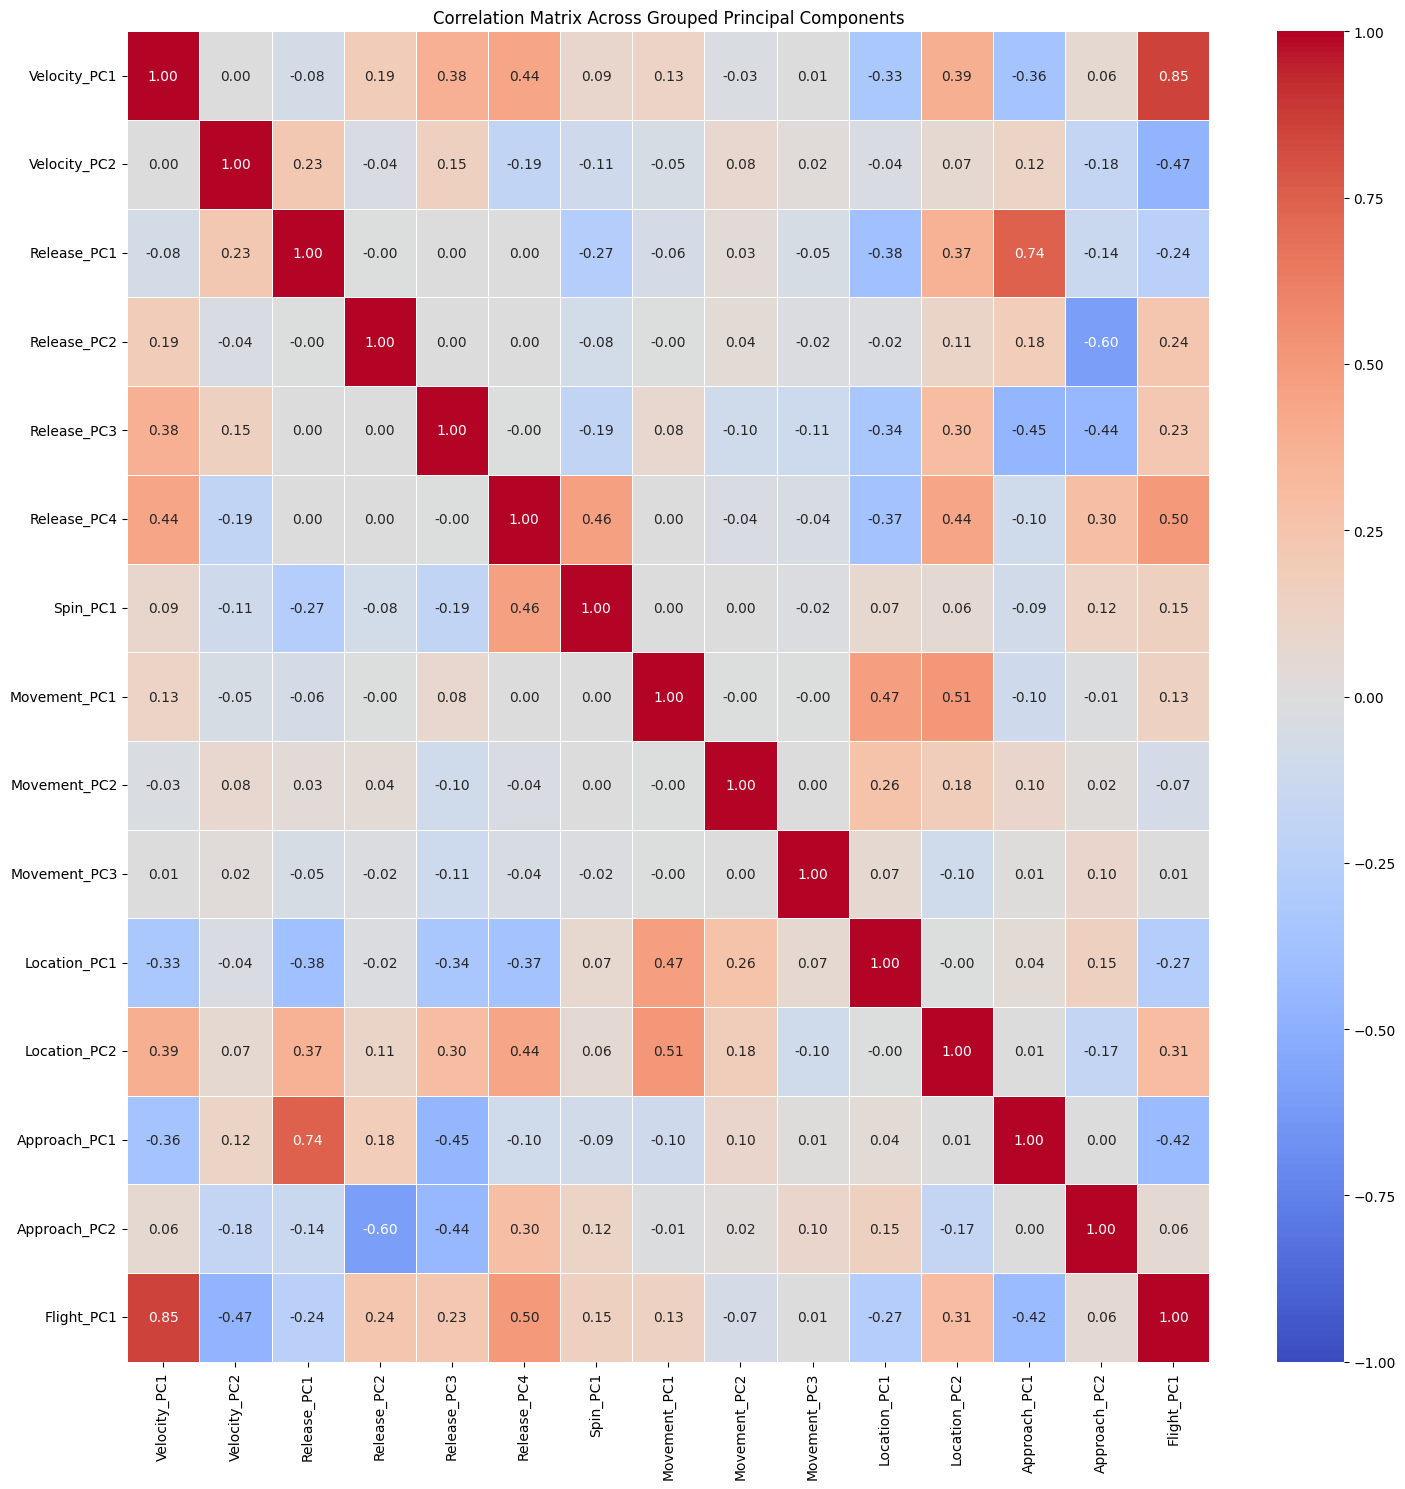

In [542]:
plt.figure(figsize=(15, 15))
sns.heatmap(
    X.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Correlation Matrix Across Grouped Principal Components")
plt.tight_layout()
plt.show()

Testing the model with PCA

In [543]:
from sklearn.cluster import KMeans

# removing Game_Context and Spin
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

X['Cluster'] = clusters

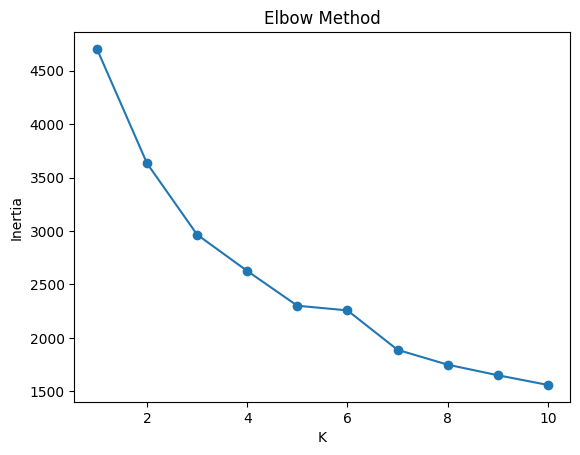

In [544]:
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    inertia.append(model.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

Cluster Sizes:
Cluster
1    143
2     71
0     45
Name: count, dtype: int64


/tmp/ipykernel_2461/2479943891.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


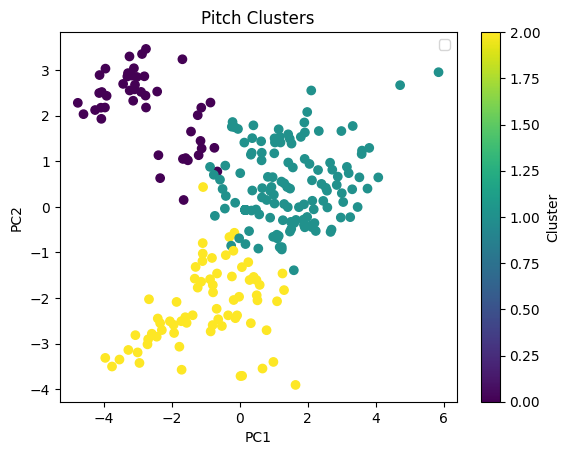


Cluster Feature Profiles:
Cluster          0     1     2
Velocity_PC1  2.14 -0.52 -0.32
Velocity_PC2 -0.13  0.09 -0.10
Release_PC1   0.12  0.83 -1.75
Release_PC2   0.38 -0.05 -0.15
Release_PC3   0.74 -0.06 -0.35
Release_PC4   1.13 -0.16 -0.39
Spin_PC1      0.10 -0.08  0.10
Movement_PC1  0.25 -0.11  0.07
Movement_PC2 -0.17  0.03  0.06
Movement_PC3 -0.03 -0.05  0.13
Location_PC1 -1.01 -0.08  0.80
Location_PC2  1.15  0.02 -0.76
Approach_PC1 -0.94  0.86 -1.14
Approach_PC2 -0.12 -0.12  0.32
Flight_PC1    1.58 -0.48 -0.03


In [545]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)
X['Cluster'] = clusters
print("Cluster Sizes:")
print(X["Cluster"].value_counts())
cluster_means = X.groupby("Cluster").mean().round(2)

X_vis = pca_vis.fit_transform(X.drop('Cluster', axis=1))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=X['Cluster'],
    cmap='viridis'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Pitch Clusters")
plt.colorbar(label="Cluster")
plt.legend()
plt.show()

print("\nCluster Feature Profiles:")
print(cluster_means.T)  # Transposed for easier scanning
pca_vis = PCA(n_components=2)

In [546]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X.drop("Cluster", axis=1), clusters)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.230


In [547]:
# Cross-tabulate KMeans clusters with ground truth pitch tags
pd.crosstab(
    X["Cluster"], df["TaggedPitchType"], margins=True
).style.background_gradient(cmap="YlGnBu")

TaggedPitchType,Change,Curve,Fast,Rise,Screw,All
Cluster,,,,,,
0,9,1,2,6,27,45
1,8,67,0,47,21,143
2,5,3,1,57,5,71
All,22,71,3,110,53,259


In [353]:
groups.keys()

dict_keys(['Velocity', 'Release', 'Movement', 'Location', 'Approach', 'Trajectory_Physics', 'Contact', 'Flight'])

In [548]:
# mapping PCA back into orignal df
# for example, velocity and movement
for key in groups.keys():
  keys_df = raw_group_dfs[key]
  key_pca = groups[key]['pca']
  smallest_n = groups[key]['smallest_n']

  loadings = pd.DataFrame(
      key_pca.components_[:smallest_n, :].T,
      columns=[f"PC{i+1}" for i in range(smallest_n)],
      index=keys_df.columns
  )
  print(f"---- {key} Loadings ----")
  print(loadings.round(3))

---- Velocity Loadings ----
            PC1    PC2
SpinRate  0.707  0.707
pfxz      0.707 -0.707
---- Release Loadings ----
                  PC1    PC2    PC3    PC4
RelHeight      -0.505  0.083 -0.305  0.763
RelSide         0.622 -0.153 -0.146  0.127
HorzBreak      -0.538 -0.151 -0.308 -0.615
PlateLocHeight -0.102  0.789  0.483 -0.077
PlateLocSide   -0.240 -0.569  0.747  0.133
---- Spin Loadings ----
           PC1
Extension  1.0
---- Movement Loadings ----
                  PC1    PC2    PC3
PositionAt110X -0.530  0.684  0.502
PositionAt110Y  0.681 -0.009  0.732
PositionAt110Z  0.505  0.730 -0.461
---- Location Loadings ----
            PC1    PC2
HangTime  0.707  0.707
pfxx     -0.707  0.707
---- Approach Loadings ----
       PC1    PC2
x0  -0.697 -0.137
z0  -0.151  0.988
vx0  0.701  0.076
---- Flight Loadings ----
     PC1
az0  1.0


In [549]:
crosstab = pd.crosstab(
    df['TaggedPitchType'],
    X['Cluster'],
    normalize='index'
).round(2)

print("---- Cluster TaggedPitchType Crosstab ----")
print(crosstab)

---- Cluster TaggedPitchType Crosstab ----
Cluster             0     1     2
TaggedPitchType                  
Change           0.41  0.36  0.23
Curve            0.01  0.94  0.04
Fast             0.67  0.00  0.33
Rise             0.05  0.43  0.52
Screw            0.51  0.40  0.09


In [557]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X)

df['UMAP_1'] = embedding[:, 0]
df['UMAP_2'] = embedding[:, 1]

# Combine UMAP with HDBSCAN for state-of-the-art pitch identification
df['UMAP_HDBSCAN_Cluster'] = hdbscan.HDBSCAN(min_cluster_size=8).fit_predict(embedding)

In [552]:
# Repertoire Breakdown per Pitcher
df['Cluster'] = X['Cluster']
repertoire = (
    df.groupby(["Pitcher", "Cluster"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum(), axis=1)
    .round(3)
    * 100
)
repertoire.columns = [f"Cluster_{c}_%" for c in repertoire.columns]
print(repertoire)

                 Cluster_0_%  Cluster_1_%  Cluster_2_%
Pitcher                                               
Bella  Macmahon          0.0         37.5         62.5
Grace  Proctor           0.0          5.6         94.4
Keira Carrillo           0.0         27.8         72.2
Kynlee Bowlin           84.8         15.2          0.0
Maddie Furniss           0.0         98.8          1.2
Tayler Baker            11.8         86.3          2.0


In [553]:
import pandas as pd

# 1. Cross-tabulate Pitcher by Cluster (Counts)
arsenal_counts = pd.crosstab(df["Pitcher"], df["Cluster"])

# 2. Normalize by row to get percentage share per cluster (%)
arsenal_pct = (
    pd.crosstab(df["Pitcher"], df["Cluster"], normalize="index") * 100
).round(1)

# 3. Rename columns for clarity based on physical profiles
cluster_names = {
    0: "Cluster 0 (Power/Top Zone)",
    1: "Cluster 1 (High-Release Offspeed)",
    2: "Cluster 2 (Low Slot/Sweeper)",
}
arsenal_pct = arsenal_pct.rename(columns=cluster_names)

# 4. Add Total Pitches column
arsenal_pct["Total_Pitches"] = df.groupby("Pitcher").size()

# 5. Display styled summary table
print("=== PITCHER ARSENAL DISTRIBUTION (%) ===")
print(arsenal_pct)

=== PITCHER ARSENAL DISTRIBUTION (%) ===
Cluster          Cluster 0 (Power/Top Zone)  \
Pitcher                                       
Bella  Macmahon                         0.0   
Grace  Proctor                          0.0   
Keira Carrillo                          0.0   
Kynlee Bowlin                          84.8   
Maddie Furniss                          0.0   
Tayler Baker                           11.8   

Cluster          Cluster 1 (High-Release Offspeed)  \
Pitcher                                              
Bella  Macmahon                               37.5   
Grace  Proctor                                 5.6   
Keira Carrillo                                27.8   
Kynlee Bowlin                                 15.2   
Maddie Furniss                                98.8   
Tayler Baker                                  86.3   

Cluster          Cluster 2 (Low Slot/Sweeper)  Total_Pitches  
Pitcher                                                       
Bella  Macmahon        

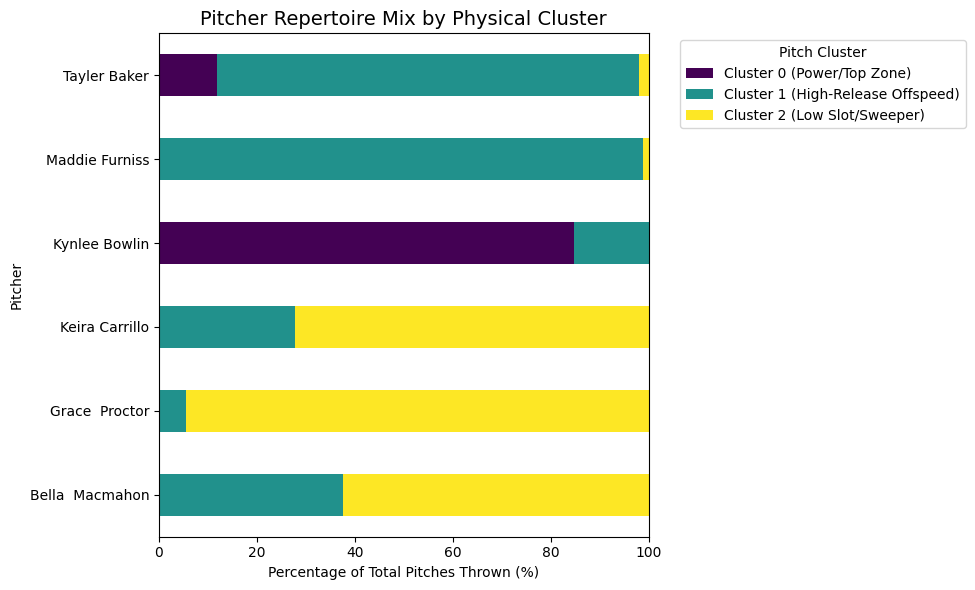

In [554]:
import matplotlib.pyplot as plt

# Plot Arsenal Breakdown
ax = arsenal_pct.drop(columns=["Total_Pitches"]).plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6),
    colormap="viridis",
)

plt.title("Pitcher Repertoire Mix by Physical Cluster", fontsize=14)
plt.xlabel("Percentage of Total Pitches Thrown (%)")
plt.ylabel("Pitcher")
plt.legend(title="Pitch Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()